# Análisis exploratorio

Micaela Gauto (Instituto Nacional de Epidemiología)  
Tamara Ricardo (Instituto Nacional de Epidemiología)

In [ ]:
knitr::opts_chunk$set(
  echo = FALSE,
  message = FALSE,
  warning = FALSE,
  fig.align = "center"
)

In [ ]:
pacman::p_load(
  rio,
  janitor,
  geoAr,
  sf,
  tmap,
  gghighlight,
  flextable,
  tidyverse
)

In [ ]:
## AVAD por provincia, sexo y grupo etario
AVAD_prov <- import("../datos_limpios/arg_sim_avad_dm2_prov.rds")

In [ ]:
## Capas GIS provincias
shp_arg <- get_geo(geo = "ARGENTINA") |>
  # Añadir ids de provincia
  add_geo_codes() |>

  # Quitar filas vacías
  drop_na() |>

  # Cambiar etiqueta CABA
  mutate(prov_nombre = if_else(codprov_censo == "02", name_prov, name_iso)) |>

  # Crear región geográfica DEIS
  # Crear región geográfica DEIS
  mutate(
    region_deis = case_when(
      codprov_censo %in% c("02", "06", "14", "30", "82") ~ "Centro",
      codprov_censo %in% c("18", "22", "34", "54") ~ "NEA",
      codprov_censo %in% c("38", "66") ~ "NOA1",
      codprov_censo %in% c("10", "86", "90") ~ "NOA2",
      codprov_censo %in% c("46", "50", "70", "74") ~ "Cuyo",
      .default = "Patagonia"
    )
  ) |>

  # Agrupar por provincia
  count(codprov_censo, prov_nombre, region_deis) |>

  # Validar geometría
  st_make_valid()

## Análisis espacial y tendencia de la carga de enfermedad por diabetes mellitus en Argentina, período 2005-2018

### Prevalencia DM2 y tasas específicas AVP, AVD y AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

In [ ]:
## Datos AVP, AVD y AVAD por año, sexo y grupo etario
tab <- AVAD_arg |>
  # Redondear cifras
  mutate(across(.cols = where(is.numeric), .fns = ~ round(.x, 2))) |>

  # Crear columna UI
  mutate(
    Prev = paste0(dm2_prev, " (", dm2_prev_low, "-", dm2_prev_upp, ")"),
    AVP = paste0(AVP_tasa, " (", AVP_tasa_low, "-", AVP_tasa_upp, ")"),
    AVD = paste0(AVD_tasa, " (", AVD_tasa_low, "-", AVD_tasa_upp, ")"),
    AVAD = paste0(
      AVAD_tasa,
      " (",
      AVAD_tasa_low,
      "-",
      AVAD_tasa_upp,
      ")"
    )
  ) |>

  # Seleccionar columnas
  select(
    anio_enfr,
    sexo,
    grupo_edad_10,
    "Prev (95% CI)" = Prev,
    "Tasa AVP (95% UI)" = AVP,
    "Tasa AVD (95% UI)" = AVD,
    "Tasa AVAD (95% UI)" = AVAD
  ) |>

  # Ordenar filas
  arrange(anio_enfr) |>

  # Pasar a formato wide
  pivot_wider(names_from = sexo, values_from = 4:7)


## Generar tabla
tab |>
  rename(
    Año = anio_enfr,
    "Grupo etario" = grupo_edad_10
  ) |>
  flextable() |>

  separate_header(split = "_") |>

  merge_v(j = 1) |>

  autofit() |>

  font(fontname = "Calibri", part = "all")

Año Grupo etario Prev (95% CI) Tasa AVP (95% UI) Tasa AVD (95% UI) Tasa AVAD (95% UI) Mujer Varón Mujer Varón Mujer Varón Mujer Varón 2005 30 a 39 0.06 (0.04-0.07) 0.03 (0.02-0.04) 1.97 (0.25-4.14) 2.02 (0.28-4.18) 375.78 (280.76-471.66) 42.45 (27.05-57.94) 377.95 (282.7-473.79) 44.48 (28.98-60.22) 40 a 49 0.05 (0.04-0.07) 0.05 (0.04-0.07) 7.93 (3.44-12.49) 9.63 (4.8-14.59) 279.77 (206.01-352.03) 399.46 (258.84-540.55) 287.65 (213.54-359.66) 409.13 (267.87-550.22) 50 a 59 0.11 (0.09-0.13) 0.11 (0.09-0.14) 30.9 (21.59-40.37) 47.15 (35.79-58.35) 950.77 (730.7-1172.17) 1582.05 (1206.51-1951.98) 981.24 (760.49-1202.16) 1629.78 (1251.73-1998.32) 60 a 69 0.18 (0.15-0.22) 0.18 (0.14-0.22) 92.95 (74.93-110.26) 135.46 (113.03-157.68) 2280.11 (1775.71-2777.28) 3433.57 (2671.97-4194.73) 2373.2 (1870.07-2872.43) 3568.69 (2810.42-4329.11) 70 a 79 0.14 (0.11-0.18) 0.16 (0.12-0.2) 197.19 (167.77-227.06) 315.96 (271.72-361.4) 2323.16 (1740.15-2900.13) 4591.6 (3286.03-5953.85) 2519.46 (1931.33-3099.79) 4908.91 (3600.17-6267.76) 80+ 0.12 (0.08-0.16) 0.21 (0.11-0.31) 310.79 (266.04-355.9) 322.75 (261.9-383.08) 1927.91 (1191.39-2646.45) 9352.53 (4349.19-14426.02) 2238.79 (1500.93-2959.29) 9680.38 (4682.32-14723.9) 2009 30 a 39 0.07 (0.06-0.08) 0.04 (0.03-0.05) 2.57 (0.45-4.94) 2.12 (0.33-4.18) 391.53 (318.67-463.54) 50.2 (38.13-62.15) 393.96 (321.4-466.46) 52.31 (40.09-64.43) 40 a 49 0.09 (0.07-0.1) 0.06 (0.05-0.08) 7.49 (3.14-11.83) 8.55 (4.06-13.02) 481.9 (395.66-564.42) 455.63 (358.09-552) 489.14 (403.29-572.24) 464.18 (366.84-560.87) 50 a 59 0.11 (0.09-0.13) 0.12 (0.1-0.14) 28.98 (20.04-37.69) 39.81 (29.53-49.79) 1018.79 (858.56-1180.7) 1580.44 (1301.53-1864.92) 1047.7 (886.37-1210.17) 1620.62 (1341.88-1903.36) 60 a 69 0.17 (0.15-0.19) 0.17 (0.15-0.2) 75.23 (59.48-90.96) 113.08 (93.61-132.17) 2410.55 (2058.26-2762.44) 3346.05 (2764.6-3935.22) 2484.93 (2133.64-2839.86) 3459.68 (2877.11-4050.87) 70 a 79 0.17 (0.14-0.2) 0.21 (0.18-0.25) 168.45 (141.56-196.24) 262.33 (220.18-303.55) 2847.91 (2369.25-3329.25) 6225.58 (4995.39-7442.26) 3017.7 (2536.75-3495.48) 6487.19 (5251.53-7704.67) 80+ 0.15 (0.12-0.19) 0.17 (0.12-0.22) 251.68 (213.96-290.24) 267.79 (215.08-319.65) 2384.04 (1790.02-2974.07) 7923.78 (5347.21-10474.39) 2638.05 (2040.37-3226.49) 8191.13 (5613.27-10733.2) 2013 30 a 39 0.07 (0.05-0.08) 0.04 (0.03-0.05) 2.21 (0.38-4.33) 2.11 (0.34-4.11) 380.43 (298.13-463.15) 58.62 (42.11-74.58) 382.64 (300.46-465.63) 60.73 (43.98-76.86) 40 a 49 0.09 (0.07-0.11) 0.08 (0.06-0.1) 7.05 (2.95-11.23) 10.49 (5.49-15.35) 509.35 (402.26-619.68) 600.9 (444.25-760.37) 516.47 (409.69-626.88) 611.58 (454.44-771.82) 50 a 59 0.13 (0.11-0.16) 0.12 (0.1-0.14) 25.57 (17.5-33.66) 39.25 (29.43-49.13) 1093.9 (868.82-1314.35) 1538.01 (1210.59-1855.67) 1119.47 (894.08-1340.07) 1577.73 (1251.46-1894.43) 60 a 69 0.16 (0.14-0.19) 0.18 (0.14-0.21) 73.76 (59.18-88.31) 106 (87.86-124.03) 2271.1 (1833.04-2696.03) 3270.52 (2602.23-3944.77) 2344.78 (1907.16-2769.22) 3377.21 (2708.97-4050.37) 70 a 79 0.18 (0.15-0.21) 0.24 (0.19-0.29) 151.84 (125.88-177.38) 236.8 (199.58-273.78) 3072.48 (2414.51-3737.25) 5729.42 (4196.99-7197.83) 3224.8 (2566.98-3891.59) 5966.83 (4435.63-7436.19) 80+ 0.13 (0.09-0.17) 0.09 (0.05-0.12) 224.08 (191.02-257.08) 265.13 (216.77-312.85) 1940.86 (1233.01-2641.21) 3457.77 (2225.56-4697.88) 2165.18 (1453.81-2864.47) 3722.03 (2483.53-4966.99) 2018 30 a 39 0.1 (0.08-0.12) 0.04 (0.03-0.05) 2.27 (0.39-4.37) 2.93 (0.74-5.23) 611.32 (490.4-731.31) 52.78 (39.41-66.11) 613.48 (492.28-733.08) 55.74 (42.01-69.28) 40 a 49 0.12 (0.1-0.14) 0.12 (0.09-0.14) 8.46 (4.19-12.7) 10.21 (5.76-14.65) 699.51 (578.88-819.27) 891.47 (686.99-1095.07) 707.92 (586.59-828.32) 901.53 (697.46-1104.14) 50 a 59 0.15 (0.13-0.18) 0.17 (0.14-0.2) 26.62 (18.78-34.57) 40.69 (30.92-50.1) 1267.87 (1056.19-1479.03) 2311.35 (1878.4-2758.12) 1293.85 (1083.36-1505.75) 2352.41 (1919.6-2800) 60 a 69 0.2 (0.17-0.23) 0.2 (0.17-0.23) 66.95 (53.51-80.78) 112.21 (94.49-129.81) 2584.94 (2205.74-2958.43) 4112.76 

### Pirámide AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

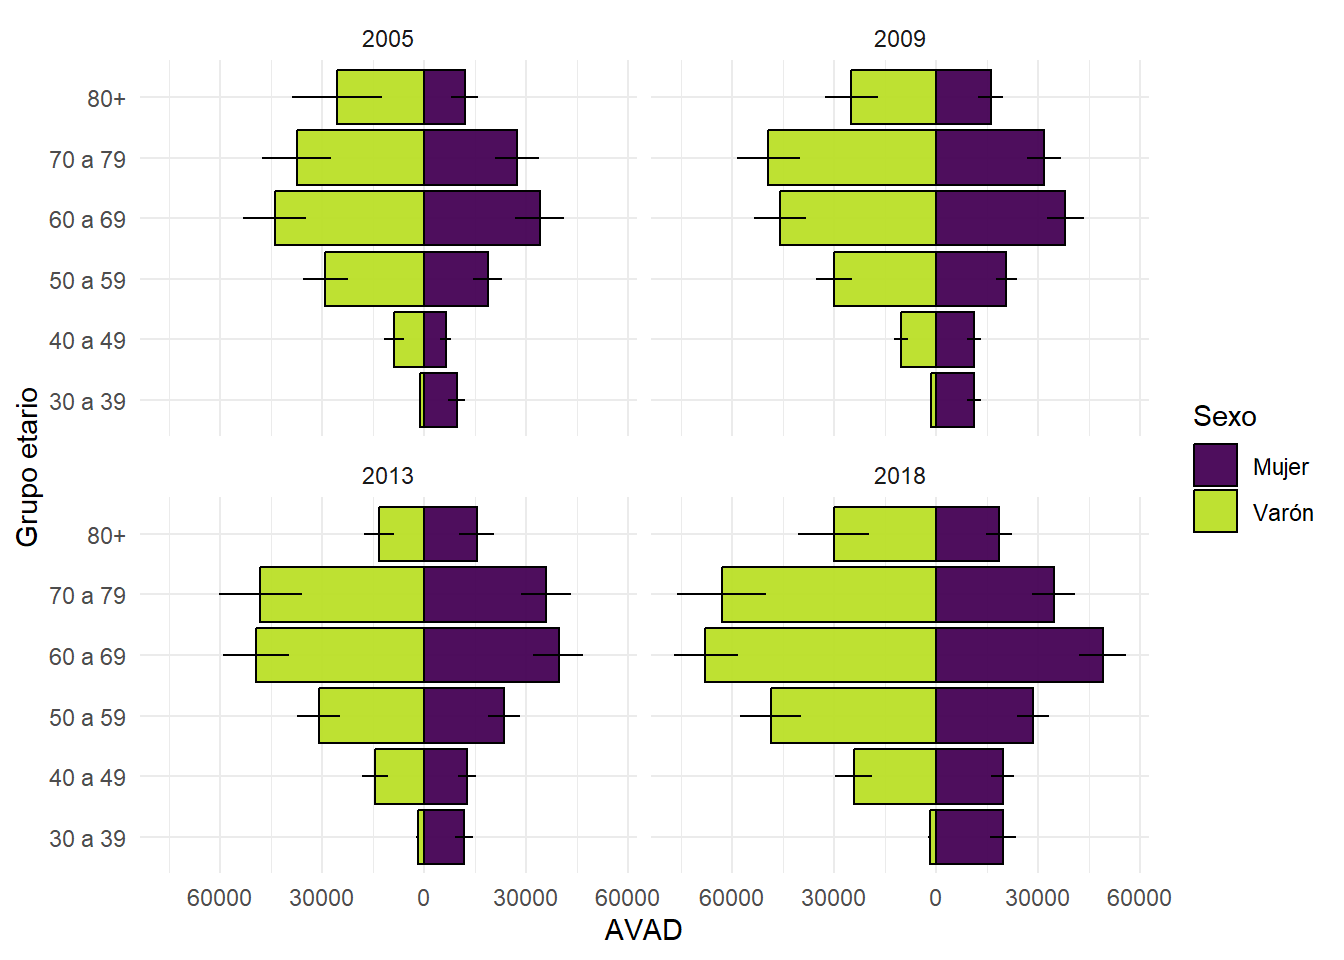

In [ ]:
## Datos para el gráfico
tab <- AVAD_arg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional con barras de error
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "black") +
  geom_linerange(aes(ymin = AVAD_low, ymax = AVAD_upp)) +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs, n.breaks = 6) +
  coord_flip() +
  labs(x = "Grupo etario", fill = "Sexo") +
  facet_wrap(~anio_enfr) +
  theme_minimal()

### Pirámide tasa AVAD por sexo y grupo etario decenal, Argentina (2005-2018)

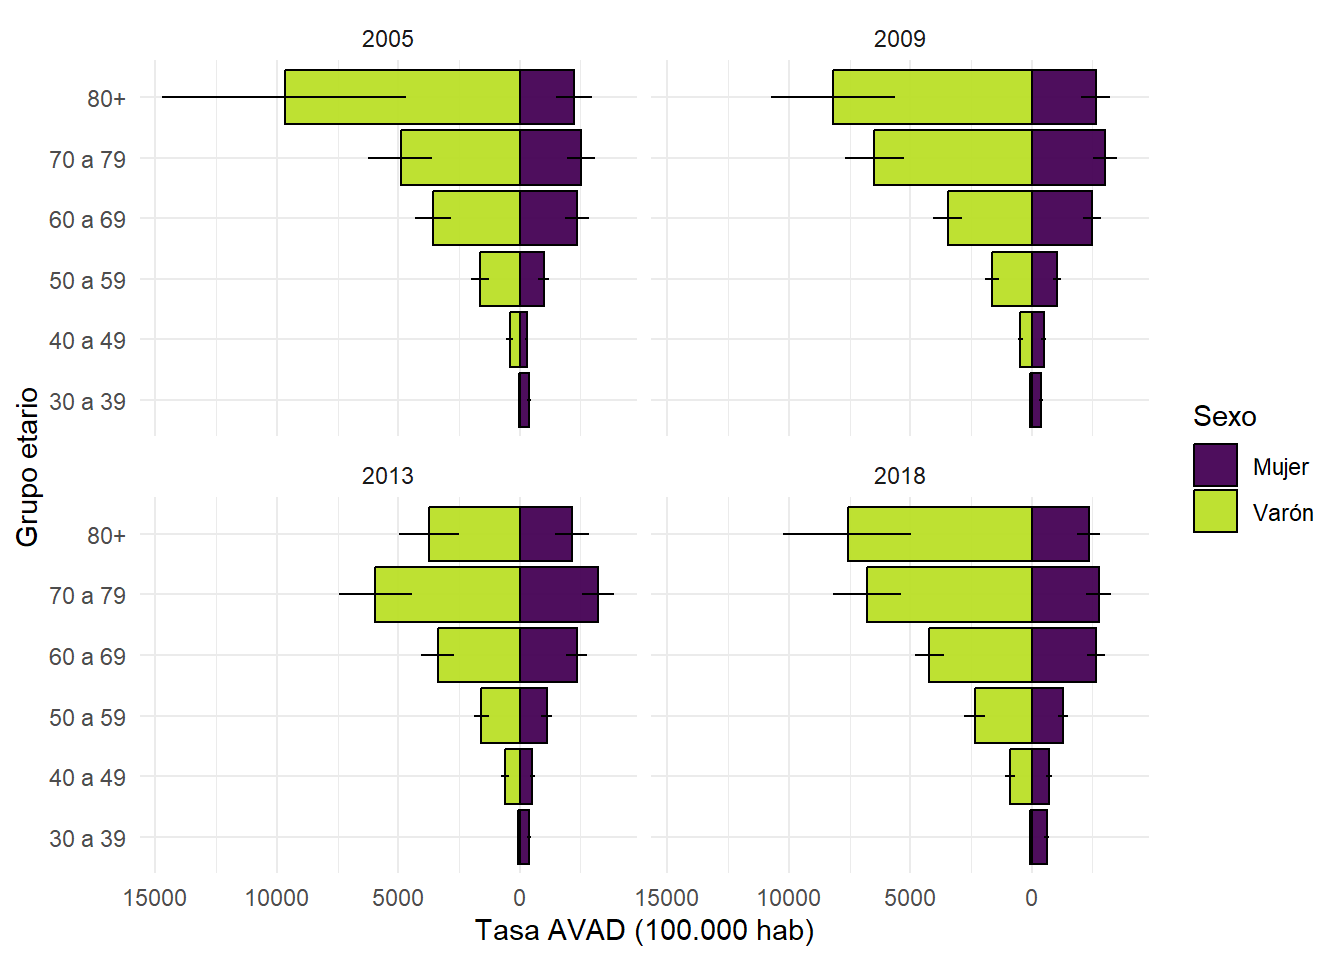

In [ ]:
## Pirámide poblacional con barras de error
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD_tasa, fill = sexo)) +
  geom_col(color = "black") +
  geom_linerange(aes(ymin = AVAD_tasa_low, ymax = AVAD_tasa_upp)) +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(x = "Grupo etario", y = "Tasa AVAD (100.000 hab)", fill = "Sexo") +
  facet_wrap(~anio_enfr) +
  theme_minimal()

### Pirámide AVAD por región, sexo y grupo etario decenal, Argentina (2005)

Falling back to ungrouped filter operation...

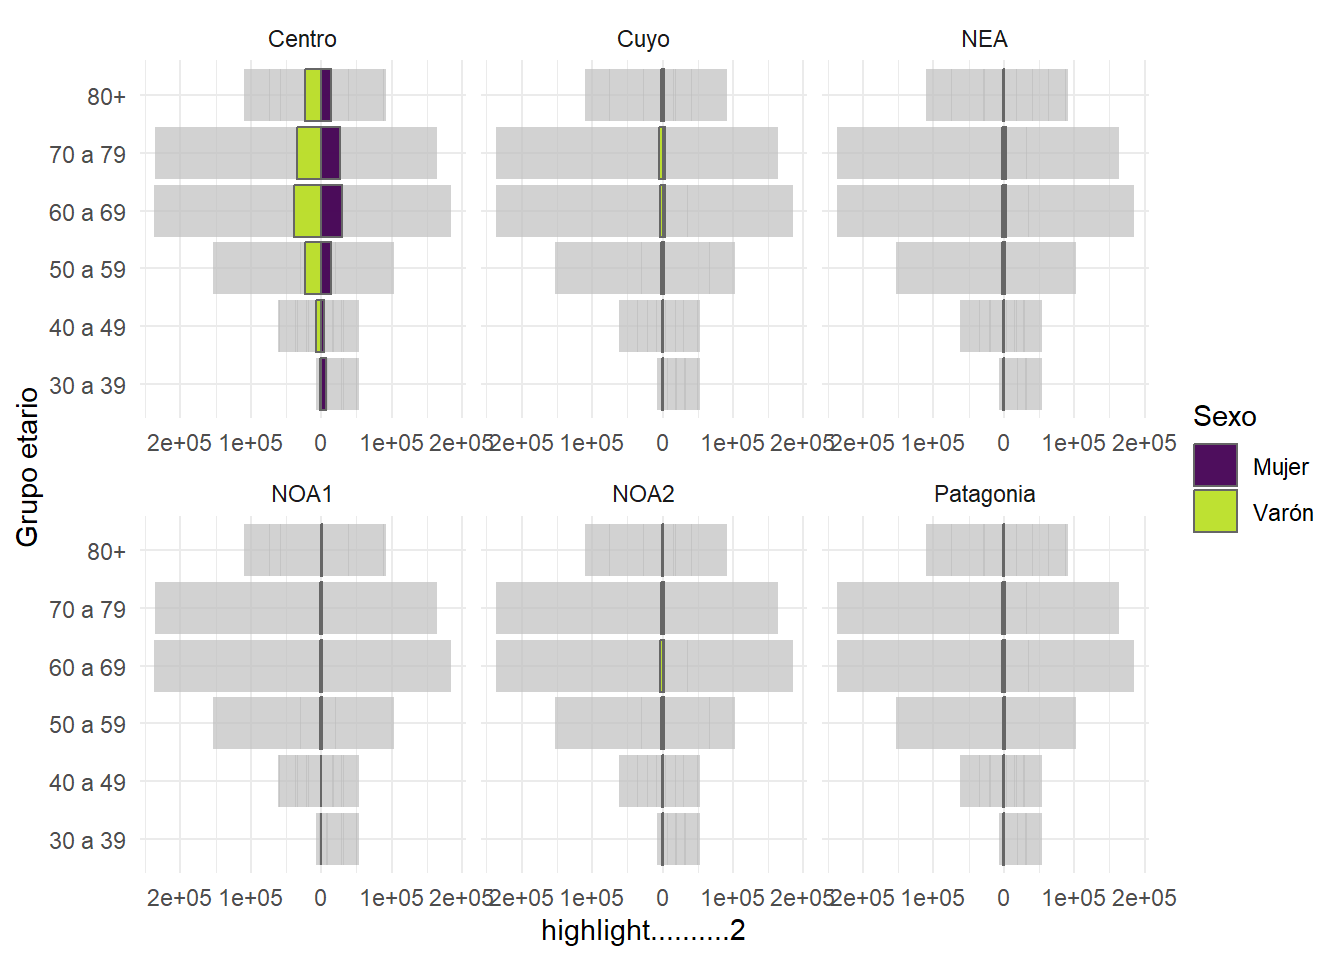

In [ ]:
## Datos para el gráfico
tab <- AVAD_reg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "grey40") +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs, n.breaks = 6) +
  coord_flip() +
  labs(x = "Grupo etario", fill = "Sexo") +
  gghighlight(anio_enfr == "2005") +
  facet_wrap(~region_deis, scales = "free_x") +
  theme_minimal()

### Pirámide tasa AVAD por región, sexo y grupo etario decenal, Argentina (2009)

Falling back to ungrouped filter operation...

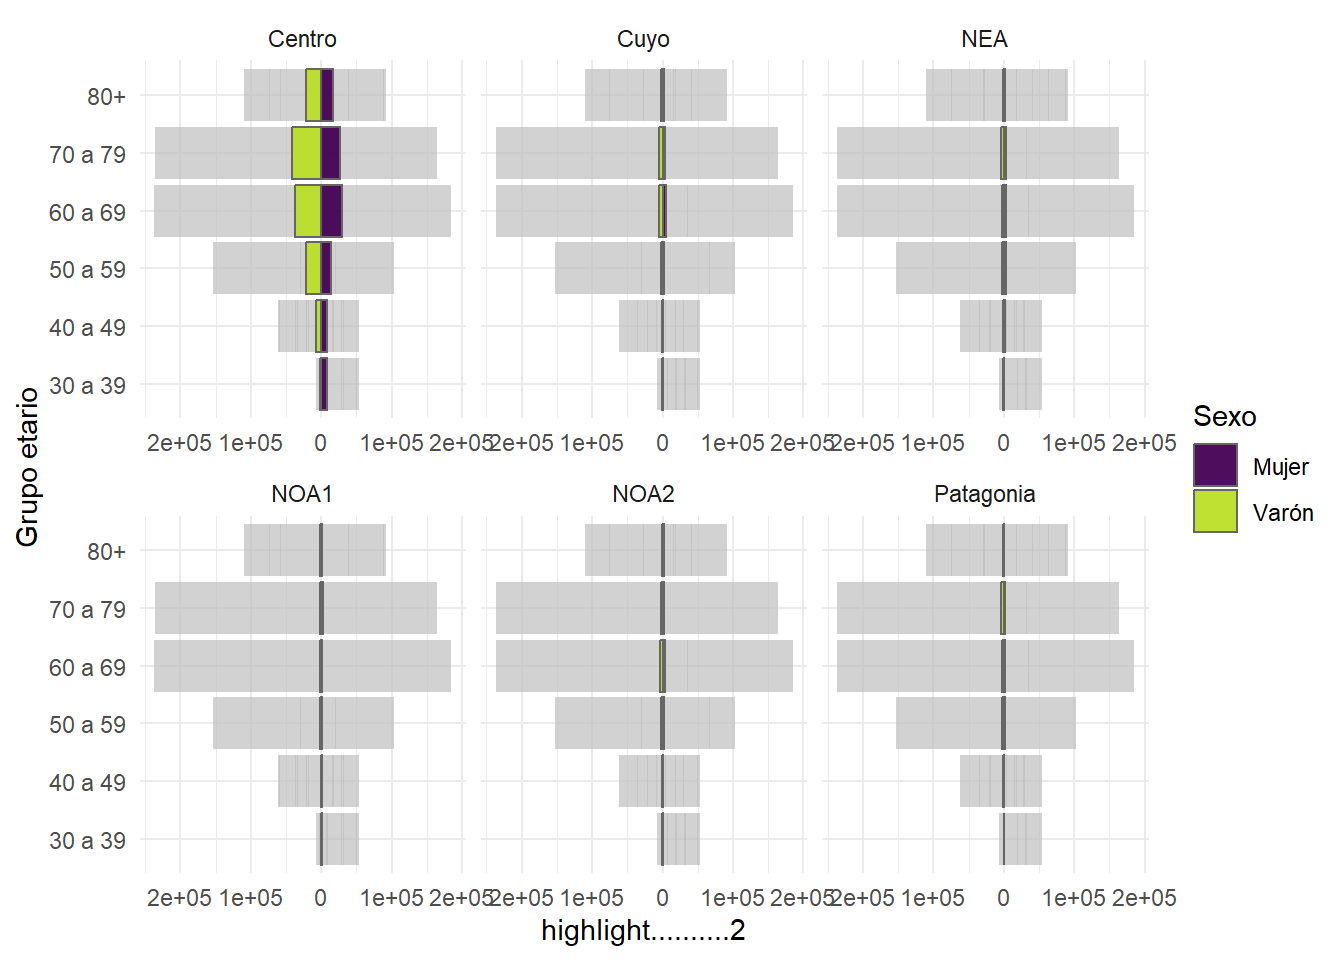

In [ ]:
## Datos para el gráfico
tab <- AVAD_reg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "grey40") +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(x = "Grupo etario", fill = "Sexo") +
  gghighlight(anio_enfr == "2009") +
  facet_wrap(~region_deis, scales = "free_x") +
  theme_minimal()

### Pirámide AVAD por región, sexo y grupo etario decenal, Argentina (2013)

Falling back to ungrouped filter operation...

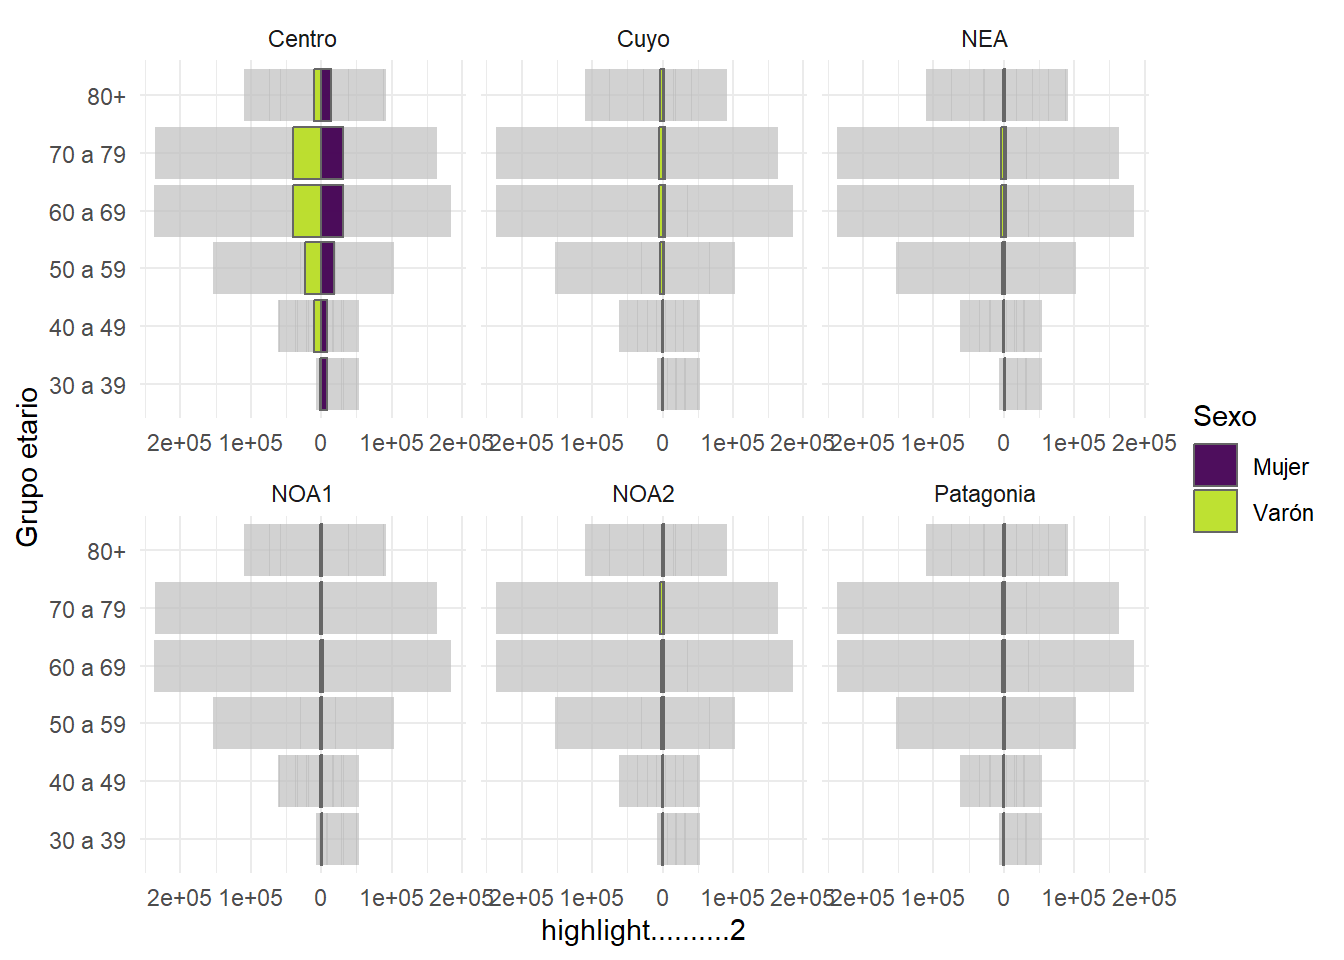

In [ ]:
## Datos para el gráfico
tab <- AVAD_reg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "grey40") +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(x = "Grupo etario", fill = "Sexo") +
  gghighlight(anio_enfr == "2013") +
  facet_wrap(~region_deis, scales = "free_x") +
  theme_minimal()

### Pirámide AVAD por región, sexo y grupo etario decenal, Argentina (2018)

Falling back to ungrouped filter operation...

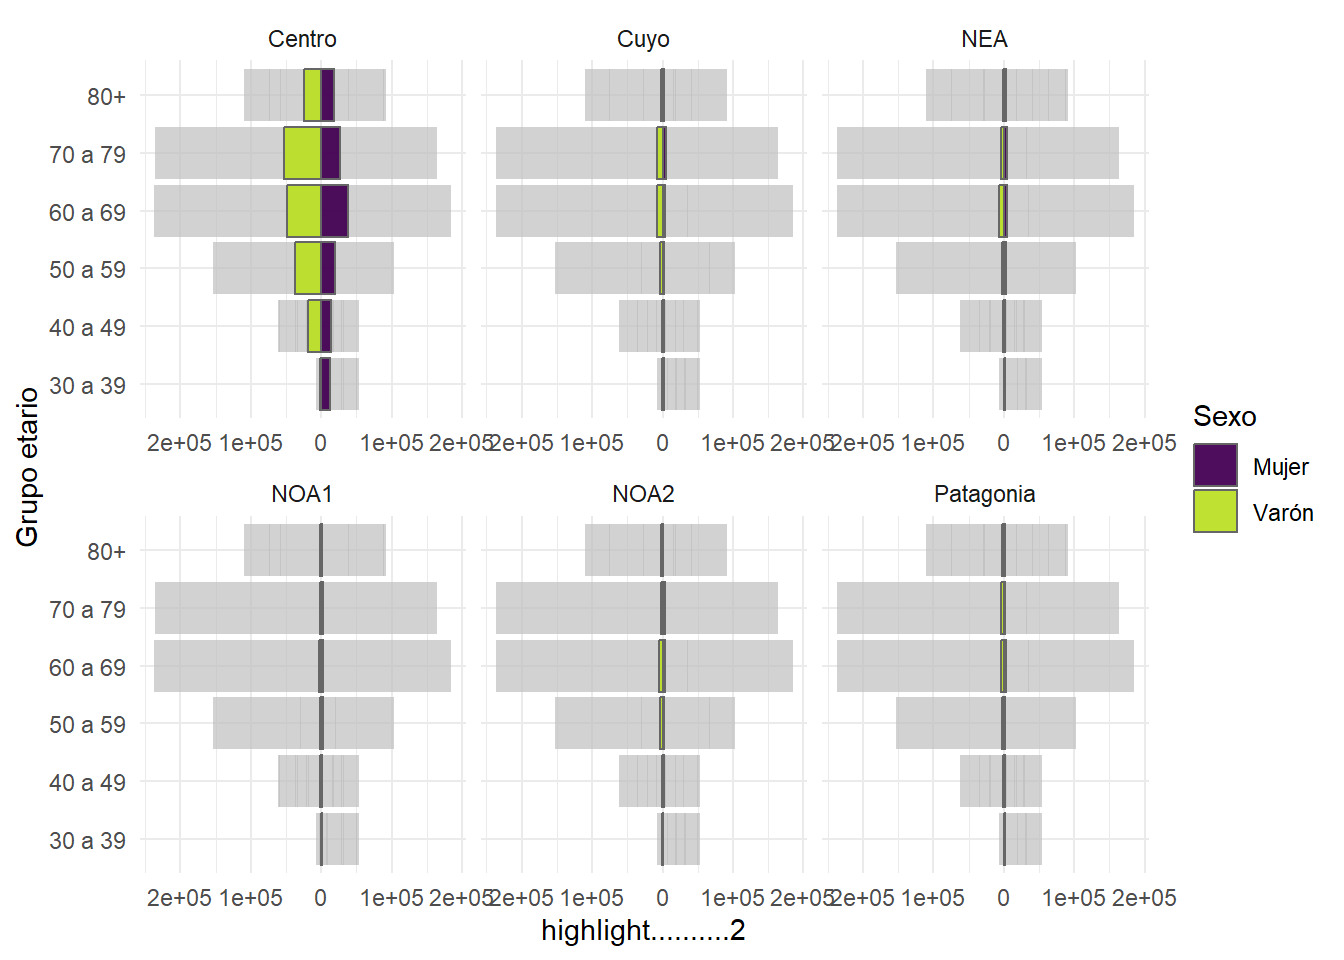

In [ ]:
## Datos para el gráfico
tab <- AVAD_reg |>
  # Seleccionar columnas
  select(anio_enfr:grupo_edad_10, contains("AVAD")) |>

  # Invertir valores para sexo masculino
  mutate(across(
    .cols = where(is.numeric),
    .fns = ~ if_else(sexo == "Mujer", .x, -.x)
  ))


## Pirámide poblacional
tab |>
  ggplot(aes(x = grupo_edad_10, y = AVAD, fill = sexo)) +
  geom_col(color = "grey40") +
  scale_fill_viridis_d(end = 0.9, alpha = 0.95) +
  scale_y_continuous(labels = abs) +
  coord_flip() +
  labs(x = "Grupo etario", fill = "Sexo") +
  gghighlight(anio_enfr == "2018") +
  facet_wrap(~region_deis, scales = "free_x") +
  theme_minimal()

### Mapa tasa AVAD por año y provincia, Argentina (2005-2018)

Joining with `by = join_by(codprov_censo)`

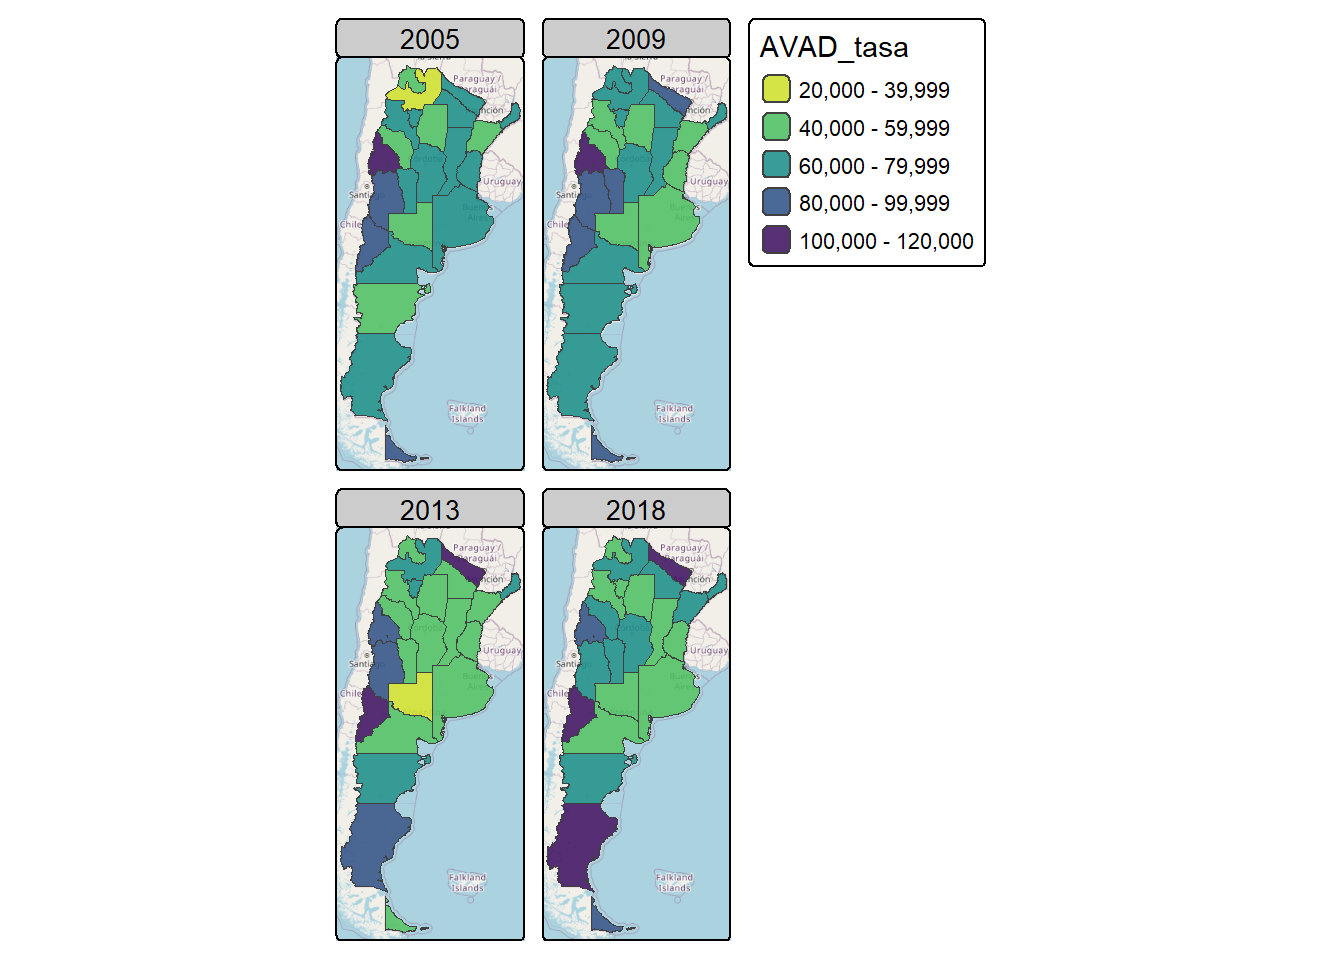

In [ ]:
## Crear objeto espacial
shp_avad <- shp_arg |>
  left_join(
    AVAD_prov |>
      count(codprov_censo, anio_enfr, wt = AVAD_tasa, name = "AVAD_tasa")
  )

### Mapa tasa AVAD por año y región DEIS, Argentina (2005-2018)

Joining with `by = join_by(region_deis)`

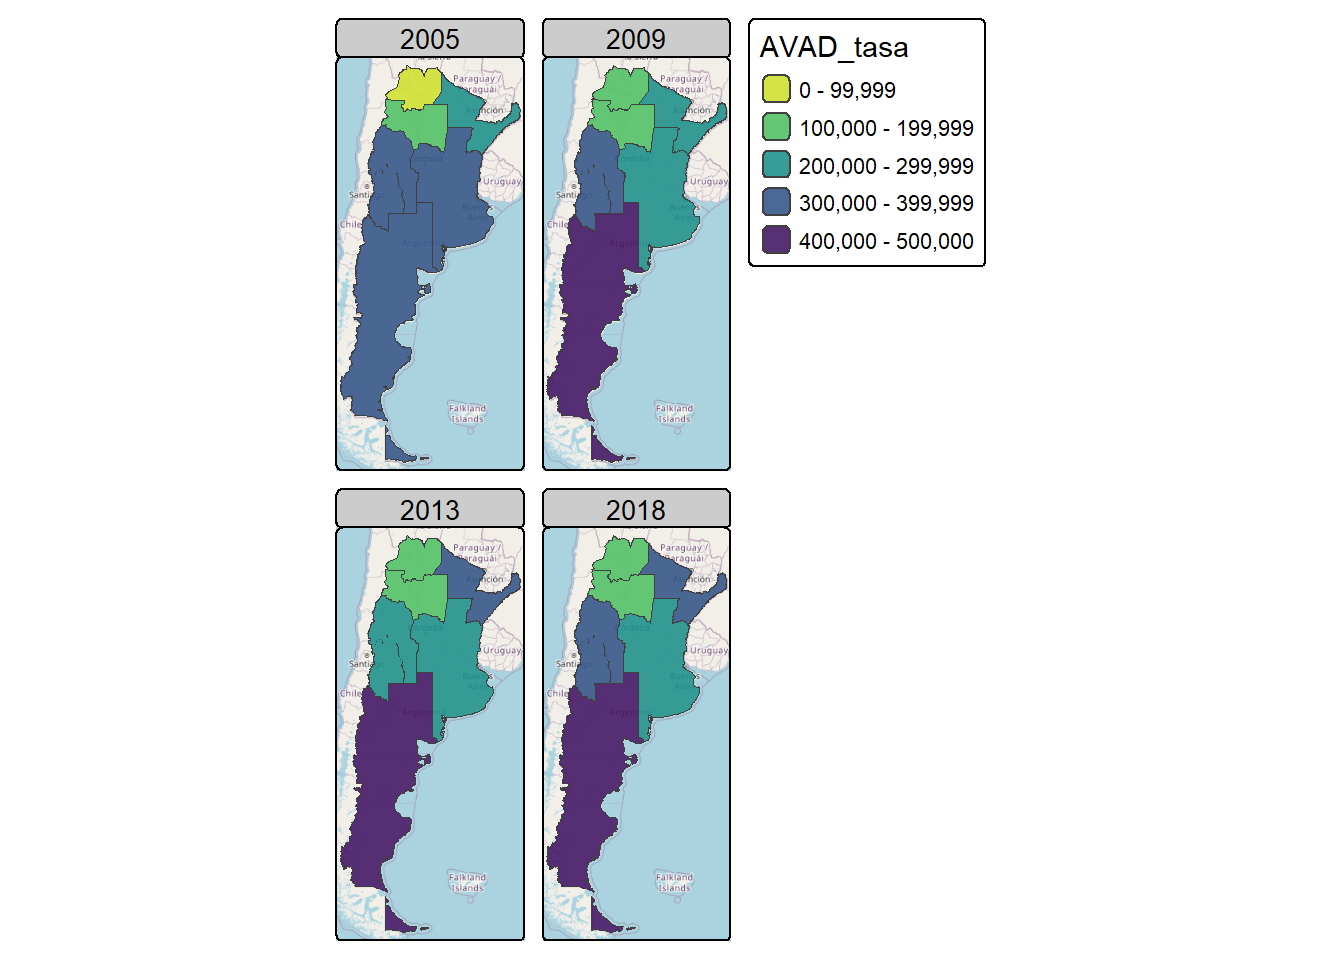

In [ ]:
## Crear objeto espacial
shp_avad <- shp_arg |>
  count(region_deis) |>
  left_join(
    AVAD_prov |>
      count(region_deis, anio_enfr, wt = AVAD_tasa, name = "AVAD_tasa")
  )